<a href="https://colab.research.google.com/github/jaidvedant/AML/blob/main/AML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Shape: (150, 4)

PCA Reduced Shape: (150, 2)
First 5 PCA Features:
          0         1
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835

LDA Reduced Shape: (150, 2)
First 5 LDA Features:
          0         1
0  8.061800 -0.300421
1  7.128688  0.786660
2  7.489828  0.265384
3  6.813201  0.670631
4  8.132309 -0.514463

PCA Accuracy: 0.9
LDA Accuracy: 1.0


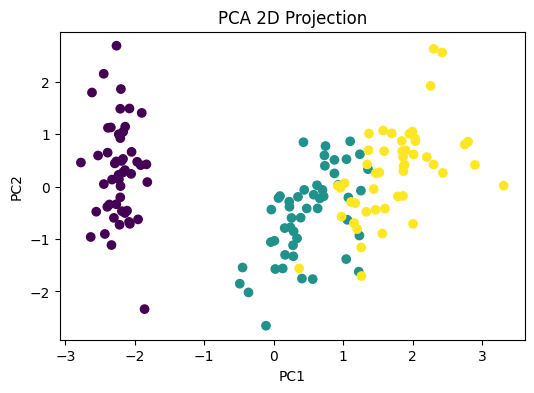

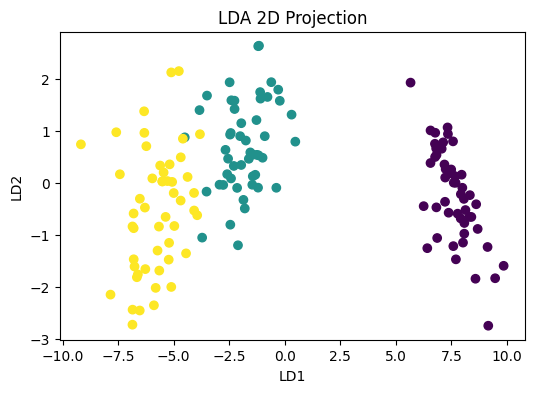

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# 1. Load Dataset
iris = load_iris()
X = iris.data
y = iris.target
print("Original Shape:", X.shape)

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 2. Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA Reduced Shape:", X_pca.shape)
print("First 5 PCA Features:")
print(pd.DataFrame(X_pca).head())


# 3. Apply LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)
print("\nLDA Reduced Shape:", X_lda.shape)
print("First 5 LDA Features:")
print(pd.DataFrame(X_lda).head())

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 5. Classification using PCA features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
model1 = LogisticRegression()
model1.fit(X_train_pca, y_train_pca)
pred1 = model1.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, pred1)
print("\nPCA Accuracy:", acc_pca)


# 6. Classification using LDA features
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y, test_size=0.2, random_state=42
)

model2 = LogisticRegression()
model2.fit(X_train_lda, y_train_lda)
pred2 = model2.predict(X_test_lda)
acc_lda = accuracy_score(y_test_lda, pred2)
print("LDA Accuracy:", acc_lda)


# 7. Plot PCA Projection
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 8. Plot LDA Projection
plt.figure(figsize=(6,4))
plt.scatter(X_lda[:,0], X_lda[:,1], c=y)
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()